In [1]:
import os

# Garante que a execução comece dentro da pasta 'tarefa4'
import pathlib
if pathlib.Path().resolve().name != 'tarefa4':
    os.chdir(os.path.join(os.getcwd(), 'deeplearning', 'tarefa4'))

%pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu121

if "sam2" not in os.listdir():
    !git clone https://github.com/facebookresearch/sam2.git
    %cd sam2
    %pip install -e .
else:
    %cd sam2

%cd checkpoints

if "sam2.1_hiera_small.pt" not in os.listdir():
    !wget -O sam2.1_hiera_small.pt "https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_small.pt"

%cd ..

%cd sam2

Note: you may need to restart the kernel to use updated packages.
/home/gustavo/codigos/MachineLearning/deeplearning/tarefa4/sam2
/home/gustavo/codigos/MachineLearning/deeplearning/tarefa4/sam2/checkpoints
/home/gustavo/codigos/MachineLearning/deeplearning/tarefa4/sam2
/home/gustavo/codigos/MachineLearning/deeplearning/tarefa4/sam2/sam2


In [2]:
import torch
import torchvision

# if torch.cuda.is_available():
#     print("CUDA is available: True")
#     print("GPU memory (in GB):", round(torch.cuda.get_device_properties(0).total_memory / 1024 / 1024 / 1024, 2))
#     device = torch.device("cuda")
# else:
print("CUDA is available: False")
print("Rodando na CPU, pois GPU não está disponível.")
device = torch.device("cpu")

print("Usando dispositivo:", device)

# Configurações extras caso esteja usando CUDA
if device.type == "cuda":
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

CUDA is available: False
Rodando na CPU, pois GPU não está disponível.
Usando dispositivo: cpu


In [3]:
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

sam2_checkpoint = "../checkpoints/sam2.1_hiera_small.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_s.yaml"

sam2_model = build_sam2(model_cfg, sam2_checkpoint, device=device)

predictor = SAM2ImagePredictor(sam2_model)

In [4]:
import kagglehub
import os
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("polomarco/chest-ct-segmentation")
print("Path to dataset files:", path)

# Estrutura do dataset: images/, masks/, pretrained_model/, train.csv
images_dir = os.path.join(path, "images", "images")
masks_dir = os.path.join(path, "masks", "masks")
train_csv_path = os.path.join(path, "train.csv")

df = pd.read_csv(train_csv_path)

df.head()


Path to dataset files: /home/gustavo/.cache/kagglehub/datasets/polomarco/chest-ct-segmentation/versions/3


,ImageId,MaskId
0,ID00007637202177411956430_0.jpg,ID00007637202177411956430_mask_0.jpg
1,ID00007637202177411956430_1.jpg,ID00007637202177411956430_mask_1.jpg
2,ID00007637202177411956430_2.jpg,ID00007637202177411956430_mask_2.jpg
3,ID00007637202177411956430_3.jpg,ID00007637202177411956430_mask_3.jpg
4,ID00007637202177411956430_4.jpg,ID00007637202177411956430_mask_4.jpg


In [5]:
image_files = df['ImageId'].tolist()
image_filename = df['ImageId'][2]
image_sample_path = os.path.join(images_dir, image_filename)

mask_files = df['MaskId'].tolist()
mask_filename = df['MaskId'][2]
mask_sample_path = os.path.join(masks_dir, mask_filename)

In [6]:
from sklearn.model_selection import train_test_split
import cv2
import numpy as np
import matplotlib.pyplot as plt

train_df, test_df = train_test_split(df, train_size=0.1, random_state=42)

# Apenas para testar as funções
train_data = [
    {
        "image": os.path.join(images_dir, row["ImageId"]),
        "annotation": os.path.join(masks_dir, row["MaskId"])
    }
    for _, row in train_df.iterrows()
]

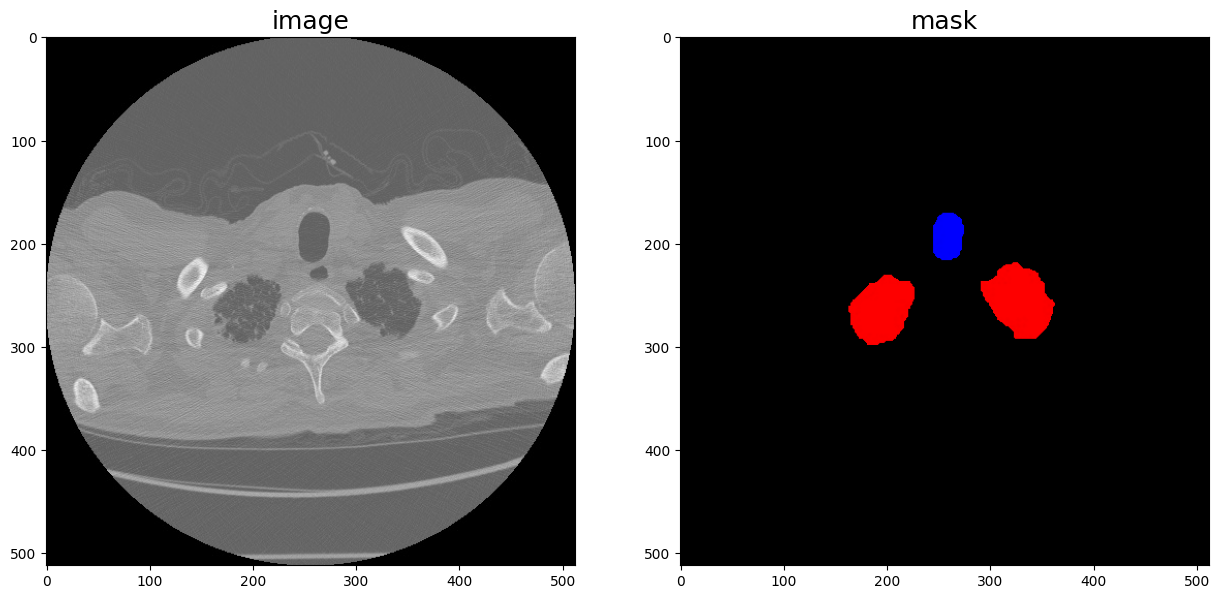

In [7]:
def get_data(img_path, mask_path):
    img = cv2.imread(img_path)
    mask = cv2.imread(mask_path)
    mask[mask < 240] = 0  # remove artifacts

    return img, mask

one_slice_img, one_slice_mask = get_data(image_sample_path, mask_sample_path)

data_to_plot = [one_slice_img, one_slice_mask]
labels = ['image', 'mask']

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 8))

for i, ax in enumerate(axes):
    ax.imshow(data_to_plot[i])
    ax.set_title(labels[i], fontdict={"fontsize": 18})

In [8]:
def visualize_batch_with_points(img, masks, points, labels):
    fig, axs = plt.subplots(2, 3, figsize=(15, 10))

    axs[0, 0].imshow(img)
    axs[0, 0].set_title('Imagem')
    axs[0, 0].axis('off')

    mask_rgb = np.stack(masks, axis=-1)
    axs[0, 1].imshow(mask_rgb)
    axs[0, 1].set_title('Máscara (RGB)')
    axs[0, 1].axis('off')

    # Overlay corrigido
    mask_overlay = (mask_rgb > 0).astype(np.float32)
    mask_color = mask_overlay * np.array([1, 0, 0])[None, None, :]
    mask_color[..., 0] = mask_overlay[..., 0]
    mask_color[..., 1] = mask_overlay[..., 1]
    mask_color[..., 2] = mask_overlay[..., 2]
    img_float = img / 255.0 if img.dtype == np.uint8 else img.copy()
    alpha = 0.3
    overlay = img_float * (1 - alpha) + mask_color * alpha
    overlay = np.clip(overlay, 0, 1)
    axs[0, 2].imshow(overlay)
    axs[0, 2].set_title('Overlay')
    axs[0, 2].axis('off')

    names = ['Lung', 'Heart', 'Trachea']
    cores = ['red', 'green', 'blue']
    for i in range(3):
        axs[1, i].imshow(masks[i], cmap='gray')
        axs[1, i].set_title(names[i])
        axs[1, i].axis('off')
        for pt, lbl in zip(points, labels):
            if lbl == i:
                axs[1, i].scatter(pt[0], pt[1], c=cores[i], s=70, marker='o', edgecolors='white', linewidths=1.5)
    plt.tight_layout()
    plt.show()

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

import cv2
import numpy as np

def get_points_from_mask(mask, min_area_ratio=0.05, erode_iter=2):
    """
    Args:
        erode_iter: Quantas vezes 'lixar' o objeto. Aumente se ainda estiverem colados.
    """
    points = []

    # 1. Garante binário
    binary_mask = (mask > 0).astype(np.uint8) * 255

    if binary_mask.sum() == 0:
        return points

    #Erosão
    kernel = np.ones((3,3), np.uint8)

    # Criamos uma máscara separada apenas para calcular os centros
    # Assim não perdemos tamanho real se precisássemos dele, mas para o ponto central é ótimo
    detection_mask = cv2.erode(binary_mask, kernel, iterations=erode_iter)

    # Se a erosão sumiu com tudo (objeto muito pequeno), volta pro original como fallback
    if detection_mask.sum() == 0:
        detection_mask = binary_mask

    # 2. Encontra componentes (agora na máscara erodida/separada)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(detection_mask, connectivity=8)

    if num_labels <= 1:
        return points

    # 3. Define threshold
    areas = stats[1:, cv2.CC_STAT_AREA]
    max_area = np.max(areas)
    min_area_threshold = max(max_area * min_area_ratio, 100)

    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]

        if area < min_area_threshold:
            continue

        # Lógica inteligente de centroide vs ponto interno
        cx, cy = int(centroids[i][0]), int(centroids[i][1])

        # Verifica na máscara erodida se o centroide é válido
        if labels[cy, cx] == i:
            points.append([cx, cy])
        else:
            # Distance Transform para achar o miolo
            component_mask = (labels == i).astype(np.uint8)
            dist_transform = cv2.distanceTransform(component_mask, cv2.DIST_L2, 5)
            _, _, _, max_loc = cv2.minMaxLoc(dist_transform)
            points.append([max_loc[0], max_loc[1]])

    return points

def read_batch(data, visualize = ""):
    """Carrega e processa dados. Retorna imagem, máscaras por canal, pontos e labels."""
    ent = data[np.random.randint(len(data))]
    img, mask = get_data(ent["image"], ent["annotation"])

    # Separa por canais
    masks = [mask[:,:,0], mask[:,:,1], mask[:,:,2]]
    class_names = ['lung', 'heart', 'trachea']

    # Resize imagem e máscaras para largura ou altura máxima de 1024
    r = np.min([1024 / img.shape[1], 1024 / img.shape[0]])  # Scaling factor
    new_shape = (int(img.shape[1] * r), int(img.shape[0] * r))
    img = cv2.resize(img, new_shape)
    masks = [cv2.resize(m, new_shape, interpolation=cv2.INTER_NEAREST) for m in masks]

    points = []
    labels = []
    for i, m in enumerate(masks):
        pts = get_points_from_mask(m)
        points += pts
        labels += [i]*len(pts)


    points = np.array(points)   # shape (Total, 2)
    labels = np.array(labels)   # shape (Total,)

    # Visualização
    if visualize == "points":
        visualize_batch_with_points(img, masks, points, labels)

    masks_formatted = [np.expand_dims(m, axis=-1) for m in masks]

    return img, masks_formatted, points, labels, mask

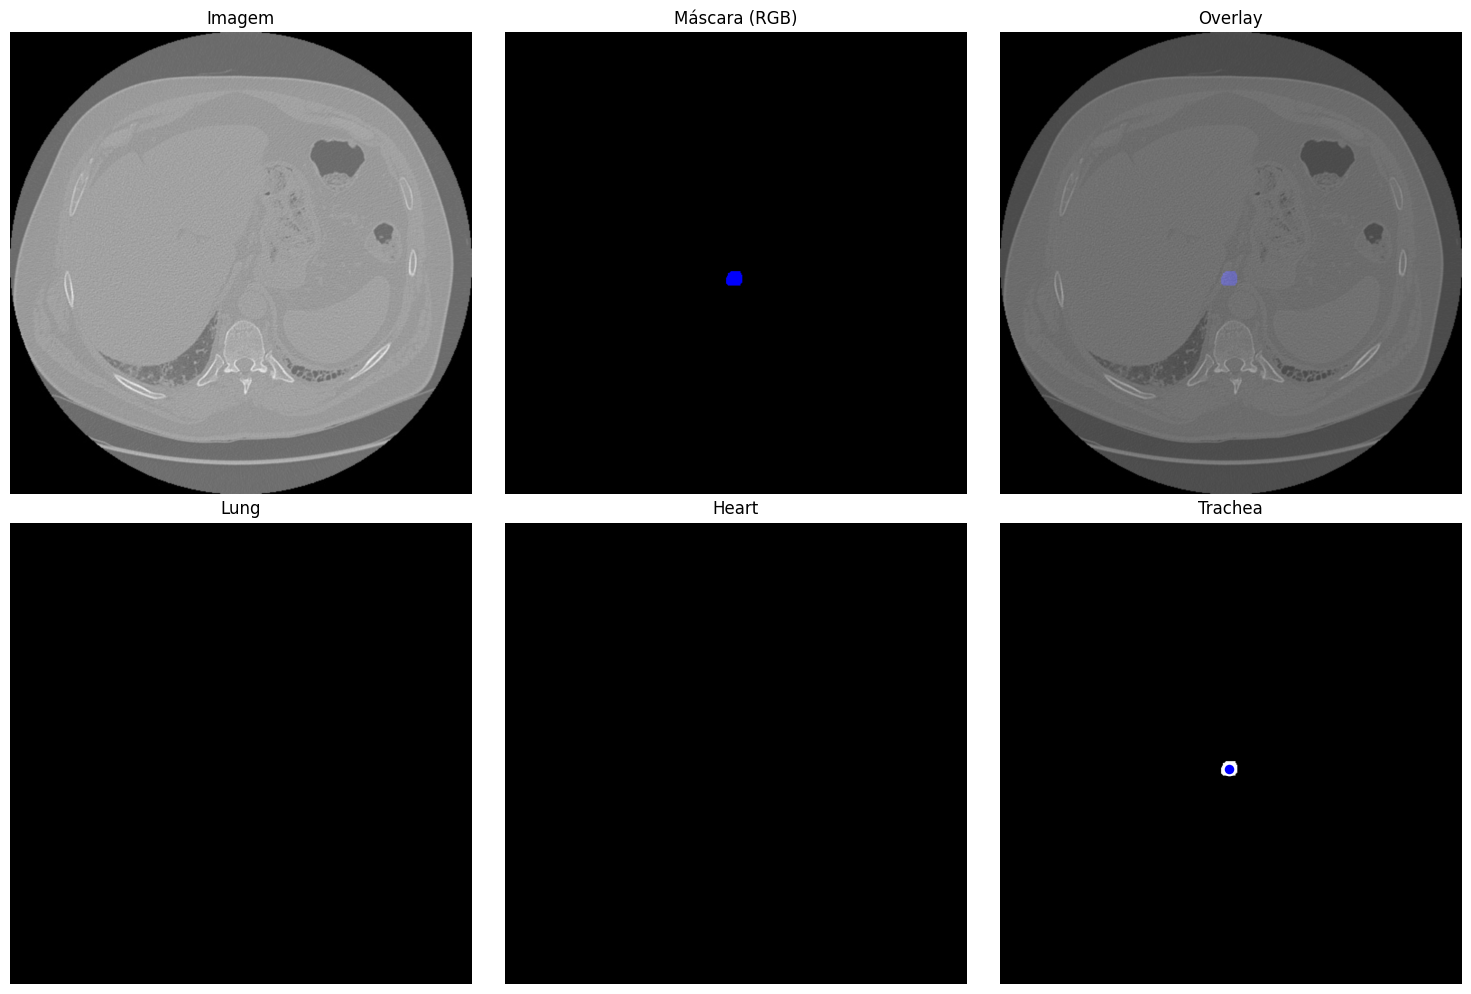

In [10]:
# Carrega e visualiza dados
img, masks, points, labels, rgb_mask = read_batch(train_data, visualize = "points")

In [11]:
def show_mask(mask, ax, random_color=False, borders = True):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask = mask.astype(np.uint8)
    mask_image =  mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    if borders:
        import cv2
        contours, _ = cv2.findContours(mask,cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        # Try to smooth contours
        contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
        mask_image = cv2.drawContours(mask_image, contours, -1, (1, 1, 1, 0.5), thickness=2)
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))

def show_masks(image, masks, scores, point_coords=None, box_coords=None, input_labels=None, borders=True):
    # Define the number of columns and rows for the subplots
    n = len(masks)
    if n > 3:
        ncols = 3
    else:
        ncols = n
    nrows = int(np.ceil(n / ncols))
    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6*ncols, 6*nrows))

    # axs is 2D array-like even if nrows=1 or ncols=1
    axs = np.array(axs).reshape(-1)
    for i, (mask, score) in enumerate(zip(masks, scores)):
        ax = axs[i]
        ax.imshow(image)
        show_mask(mask, ax, borders=borders)
        if point_coords is not None:
            assert input_labels is not None
            show_points(point_coords, input_labels, ax)
        if box_coords is not None:
            show_box(box_coords, ax)
        if len(scores) > 1:
            ax.set_title(f"Mask {i+1}, Score: {score:.3f}", fontsize=18)
        ax.axis('off')

    plt.show()

# Predict


In [12]:
# with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
#     predictor.set_image(img)

#     # Para cada classe fazemos a predição separada
#     all_masks = []
#     all_scores = []
#     all_logits = []

#     for class_id in range(3):
#         # Pega apenas os pontos da classe atual
#         class_points = points[labels == class_id]

#         if len(class_points) > 0:
#             # Label do SAM
#             class_labels = np.ones(len(class_points), dtype=np.int32)

#             masks_cls, scores_cls, logits_cls = predictor.predict(
#                 point_coords=class_points,
#                 point_labels=class_labels,
#                 multimask_output=True,
#             )

#             # Pega a melhor máscara
#             all_masks.append(masks_cls[np.argmax(scores_cls)])
#             all_scores.append(scores_cls[np.argmax(scores_cls)])
#             all_logits.append(logits_cls[np.argmax(scores_cls)])
#         else:
#             # Se não há pontos para esta classe, cria máscara vazia
#             h, w = img.shape[:2]
#             all_masks.append(np.zeros((h, w), dtype=bool))
#             all_scores.append(0.0)
#             all_logits.append(None)

#     masks = np.array(all_masks)
#     scores = np.array(all_scores)
#     logits = all_logits

In [13]:
# # Mostra as máscaras de cada classe com seus respectivos pontos
# class_names = ['Lung', 'Heart', 'Trachea']
# fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# for i in range(3):
#     ax = axs[i]
#     ax.imshow(img)
#     show_mask(masks[i], ax, borders=True)

#     # Mostra os pontos da classe i
#     class_points = points[labels == i]
#     if len(class_points) > 0:
#         # Todos os pontos são foreground (label=1)
#         class_labels = np.ones(len(class_points), dtype=np.int32)
#         show_points(class_points, class_labels, ax)

#     ax.set_title(f"{class_names[i]}\nScore: {scores[i]:.3f}", fontsize=14)
#     ax.axis('off')

# plt.tight_layout()
# plt.show()

In [14]:
# for _ in range(20):
#     img, masks, points, labels, rgb_mask = read_batch(train_data, visualize = "points")

#     with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
#         predictor.set_image(img)

#         # Para cada classe fazemos a predição separada
#         all_masks = []
#         all_scores = []
#         all_logits = []

#         for class_id in range(3):
#             # Pega apenas os pontos da classe atual
#             class_points = points[labels == class_id]

#             if len(class_points) > 0:
#                 # Label do SAM
#                 class_labels = np.ones(len(class_points), dtype=np.int32)

#                 masks_cls, scores_cls, logits_cls = predictor.predict(
#                     point_coords=class_points,
#                     point_labels=class_labels,
#                     multimask_output=True,
#                 )

#                 # Pega a melhor máscara
#                 all_masks.append(masks_cls[np.argmax(scores_cls)])
#                 all_scores.append(scores_cls[np.argmax(scores_cls)])
#                 all_logits.append(logits_cls[np.argmax(scores_cls)])
#             else:
#                 # Se não há pontos para esta classe, cria máscara vazia
#                 h, w = img.shape[:2]
#                 all_masks.append(np.zeros((h, w), dtype=bool))
#                 all_scores.append(0.0)
#                 all_logits.append(None)

#         masks = np.array(all_masks)
#         scores = np.array(all_scores)
#         logits = all_logits

#     # Mostra as máscaras de cada classe com seus respectivos pontos
#     class_names = ['Lung', 'Heart', 'Trachea']
#     fig, axs = plt.subplots(1, 3, figsize=(18, 6))

#     for i in range(3):
#         ax = axs[i]
#         ax.imshow(img)
#         show_mask(masks[i], ax, borders=True)

#         # Mostra os pontos da classe i
#         class_points = points[labels == i]
#         if len(class_points) > 0:
#             # Todos os pontos são foreground (label=1)
#             class_labels = np.ones(len(class_points), dtype=np.int32)
#             show_points(class_points, class_labels, ax)

#         ax.set_title(f"{class_names[i]}\nScore: {scores[i]:.3f}", fontsize=14)
#         ax.axis('off')

#     plt.tight_layout()
#     plt.show()

# Fine-tuning - V1


In [15]:
# Separar dataset em treino (80%), validação (5%) e teste (15%)
from sklearn.model_selection import train_test_split

train_val_df, test_df = train_test_split(df, test_size=0.15, random_state=42)
train_df, val_df = train_test_split(train_val_df, test_size=0.05/0.85, random_state=42)

# Prepara listas de dados
train_data = [
    {
        "image": os.path.join(images_dir, row["ImageId"]),
        "annotation": os.path.join(masks_dir, row["MaskId"])
    }
    for _, row in train_df.iterrows()
]

val_data = [
    {
        "image": os.path.join(images_dir, row["ImageId"]),
        "annotation": os.path.join(masks_dir, row["MaskId"])
    }
    for _, row in val_df.iterrows()
]

test_data = [
    {
        "image": os.path.join(images_dir, row["ImageId"]),
        "annotation": os.path.join(masks_dir, row["MaskId"])
    }
    for _, row in test_df.iterrows()
]

print(f"Treino: {len(train_data)}, Validação: {len(val_data)}, Teste: {len(test_data)}")

Treino: 13365, Validação: 836, Teste: 2507


In [16]:
!pip install -q git+https://github.com/huggingface/transformers.git
!pip install -q monai

In [ ]:
def get_data(img_path, mask_path):
    img = cv2.imread(img_path)
    mask = cv2.imread(mask_path)
    mask[mask < 240] = 0  # remove artifacts

    return img, mask

def get_points_from_mask(mask, min_area_ratio=0.05, erode_iter=2):
    """
    Args:
        erode_iter: Quantas vezes 'lixar' o objeto. Aumente se ainda estiverem colados.
    """
    points = []

    # 1. Garante binário
    binary_mask = (mask > 0).astype(np.uint8) * 255

    if binary_mask.sum() == 0:
        return points

    #Erosão
    kernel = np.ones((3,3), np.uint8)

    # Criamos uma máscara separada apenas para calcular os centros
    # Assim não perdemos tamanho real se precisássemos dele, mas para o ponto central é ótimo
    detection_mask = cv2.erode(binary_mask, kernel, iterations=erode_iter)

    # Se a erosão sumiu com tudo (objeto muito pequeno), volta pro original como fallback
    if detection_mask.sum() == 0:
        detection_mask = binary_mask

    # 2. Encontra componentes (agora na máscara erodida/separada)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(detection_mask, connectivity=8)

    if num_labels <= 1:
        return points

    # 3. Define threshold
    areas = stats[1:, cv2.CC_STAT_AREA]
    max_area = np.max(areas)
    min_area_threshold = max(max_area * min_area_ratio, 100)

    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]

        if area < min_area_threshold:
            continue

        # Lógica inteligente de centroide vs ponto interno
        cx, cy = int(centroids[i][0]), int(centroids[i][1])

        # Verifica na máscara erodida se o centroide é válido
        if labels[cy, cx] == i:
            points.append([cx, cy])
        else:
            # Distance Transform para achar o miolo
            component_mask = (labels == i).astype(np.uint8)
            dist_transform = cv2.distanceTransform(component_mask, cv2.DIST_L2, 5)
            _, _, _, max_loc = cv2.minMaxLoc(dist_transform)
            points.append([max_loc[0], max_loc[1]])

    return points

In [77]:
from torch.utils.data import Dataset

class SAMDataset(Dataset):
    def __init__(self, dataset, processor):
        self.dataset = dataset
        self.processor = processor

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        ent = self.dataset[idx]
        img, mask = get_data(ent["image"], ent["annotation"])

        # Separa por canais
        masks = [mask[:,:,0], mask[:,:,1], mask[:,:,2]]

        # Cria uma máscara combinada que tem valor 1 em qualquer pixel onde qualquer uma das três máscaras tem valor > 0
        combined_mask = ((masks[0] > 0) | (masks[1] > 0) | (masks[2] > 0)).astype(np.uint8)

        # Resize imagem e máscaras para largura ou altura máxima de 1024
        r = np.min([1024 / img.shape[1], 1024 / img.shape[0]])  # Scaling factor
        new_shape = (int(img.shape[1] * r), int(img.shape[0] * r))
        img = cv2.resize(img, new_shape)

        mask = cv2.resize(combined_mask, new_shape, interpolation=cv2.INTER_NEAREST)
        mask = (mask > 0).astype(np.uint8)  # garante que só há 0 ou 1

        # get bounding box prompt
        prompt = get_points_from_mask(mask)

        # Formatar para o processor
        if len(prompt) == 0:
            # dummy point - formato: [[[x, y]]]
            prompt = [[[0.0, 0.0]]]
        else:
            # Converter numpy para lista se necessário
            if isinstance(prompt, np.ndarray):
                prompt = prompt.tolist()
            # Adicionar dimensão externa: [[x, y], ...] -> [[[x, y], ...]]
            # O processor espera: [[[x1, y1], [x2, y2], ...]]
            prompt = [prompt]

        # prepare image and prompt for the model
        inputs = self.processor(img, input_points=prompt, return_tensors="pt")

        # remove batch dimension which the processor adds by default
        inputs = {k: v.squeeze(0) for k, v in inputs.items()}

        # add ground truth segmentation
        inputs["ground_truth_mask"] = mask

        return inputs

In [78]:
from transformers import SamProcessor

processor = SamProcessor.from_pretrained("facebook/sam-vit-base")

In [79]:
train_dataset = SAMDataset(dataset=train_data[:100], processor=processor)

In [65]:
example = train_dataset[0]
for k,v in example.items():
  print(k,v.shape)

pixel_values torch.Size([3, 1024, 1024])
original_sizes torch.Size([2])
reshaped_input_sizes torch.Size([2])
input_points torch.Size([2, 1, 2])
ground_truth_mask (1024, 1024)


In [80]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_dataset, batch_size=1, shuffle=True)

In [67]:
batch = next(iter(train_dataloader))
for k,v in batch.items():
  print(k,v.shape)

pixel_values torch.Size([1, 3, 1024, 1024])
original_sizes torch.Size([1, 2])
reshaped_input_sizes torch.Size([1, 2])
input_points torch.Size([1, 2, 1, 2])
ground_truth_mask torch.Size([1, 1024, 1024])


In [ ]:
from transformers import SamModel

model = SamModel.from_pretrained("facebook/sam-vit-base")

# make sure we only compute gradients for mask decoder
for name, param in model.named_parameters():
  if name.startswith("vision_encoder") or name.startswith("prompt_encoder"):
    param.requires_grad_(False)

model.safetensors:   0%|          | 0.00/375M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

SamModel LOAD REPORT from: facebook/sam-vit-base
Key                                                  | Status  | 
-----------------------------------------------------+---------+-
prompt_encoder.shared_embedding.positional_embedding | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing form the checkpoint. Consider training on your downstream task.


In [81]:
from torch.optim import Adam
import monai

# Note: Hyperparameter tuning could improve performance here
optimizer = Adam(model.mask_decoder.parameters(), lr=1e-5, weight_decay=0)

seg_loss = monai.losses.DiceCELoss(sigmoid=True, squared_pred=True, reduction='mean')

In [ ]:
from tqdm import tqdm
from statistics import mean
import torch
from torch.nn.functional import threshold, normalize

num_epochs = 10

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

model.train()
for epoch in range(num_epochs):
    epoch_losses = []
    for batch in tqdm(train_dataloader):
      # forward pass
      outputs = model(pixel_values=batch["pixel_values"].to(device),
                      input_points=batch["input_points"].to(device),
                      multimask_output=False)

      # compute loss
      predicted_masks = outputs.pred_masks.squeeze(1)
      ground_truth_masks = batch["ground_truth_mask"].float().to(device)
      loss = seg_loss(predicted_masks, ground_truth_masks.unsqueeze(1))

      # backward pass (compute gradients of parameters w.r.t. loss)
      optimizer.zero_grad()
      loss.backward()

      # optimize
      optimizer.step()
      epoch_losses.append(loss.item())

    print(f'EPOCH: {epoch}')
    print(f'Mean loss: {mean(epoch_losses)}')

  0%|          | 0/100 [00:00<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 768.00 MiB. GPU 0 has a total capacity of 3.81 GiB of which 286.69 MiB is free. Process 57801 has 1.93 GiB memory in use. Including non-PyTorch memory, this process has 1.60 GiB memory in use. Of the allocated memory 1.45 GiB is allocated by PyTorch, and 59.16 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

: 